# Manipulation de données avec pandas


Pour avoir accès aux fonctionnalités de `pandas`, il est de coutume de charger la librairie en lui accordant l'alias `pd`. Nous allons également utiliser des fonctions de `numpy` et des outils de visualisation de ```matplotlib.pyplot```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Pandas fournit essentiellement deux structures de données pour manipuler les données, ce sont les `Series` et les `Dataframe`

## Les `Series`

Une série est un tableau étiqueté unidimensionnel pouvant contenir tout type de données. Lors de l'affichage la (ou les)  première(s) colonne(s) contiennent les étiquettes qui représentent l'index de la série


In [2]:
dict_club={1:'Arsenal',2:'Aston Villa',5:'Chelsea',7:'Everton',8:'Leeds United'}
serie_club_d=pd.Series(dict_club)
print(f'Avec un dict, serie_club_d :\n{serie_club_d}')

serie_club=pd.Series(['Arsenal','Aston Villa','Chelsea','Everton','Leeds United'],index=[1,2,5,7,8])
print(f'Avec index renseigné, serie_club :\n{serie_club}')

#Sans index renseigné, une indexation est définie par défaut
serie_club2=pd.Series(['Arsenal','Aston Villa','Chelsea','Everton','Leeds United'])
print(f'Sans index renseigné\n{serie_club2}')

#Avec une double indexation 
serie_club_3=pd.Series(['Arsenal','Aston Villa','Chelsea','AS Monaco','Angers SCO'],index=[['English Premier League']*3+['French Ligue 1']*2,[1,2,3,1,2]])
print(f'Avec une double indexation\n{serie_club_3}')

Avec un dict, serie_club_d :
1         Arsenal
2     Aston Villa
5         Chelsea
7         Everton
8    Leeds United
dtype: object
Avec index renseigné, serie_club :
1         Arsenal
2     Aston Villa
5         Chelsea
7         Everton
8    Leeds United
dtype: object
Sans index renseigné
0         Arsenal
1     Aston Villa
2         Chelsea
3         Everton
4    Leeds United
dtype: object
Avec une double indexation
English Premier League  1        Arsenal
                        2    Aston Villa
                        3        Chelsea
French Ligue 1          1      AS Monaco
                        2     Angers SCO
dtype: object


Si on veut ajouter des noms à la série ou à l'index :

In [3]:
serie_club.name='Nom club'
serie_club.index.name='Id_club'
print(serie_club)

Id_club
1         Arsenal
2     Aston Villa
5         Chelsea
7         Everton
8    Leeds United
Name: Nom club, dtype: object


Si on veut récupérer l'ensemble des valeurs de la série ou de l'index :

In [4]:
print(serie_club.values)
print(type(serie_club.values))
print(serie_club.index.values)

['Arsenal' 'Aston Villa' 'Chelsea' 'Everton' 'Leeds United']
<class 'numpy.ndarray'>
[1 2 5 7 8]


Pour interroger les valeurs stockées dans un objet `Series` on peut fonctionner de différentes manières. La méthode `iloc` fournit une méthode de sélection selon la position de l'élément voulu alors que `loc` exploite la valeur de l'index. L'opérateur d'indexation `[]` appliqué directement à un objet `Series` peut être également utilisé mais il faut être conscient de son comportement qui correspond soit à celui de `loc` soit à celui de `iloc` selon la valeur passée. Lorsque les deux traitements sont possibles le comportement adopté est celui de la méthode `loc`

In [5]:
print(serie_club)
print('serie_club.loc[1] : ',serie_club.loc[1])
print('serie_club[1] : ',serie_club[1])
print(f'serie_club[[1,7]] :\n{serie_club[[1,7]]}')
print(f'serie_club.iloc[1] : {serie_club.iloc[1]}')
print(f'serie_club.iloc[0:3] :\n{serie_club.iloc[0:3]}')
print(f'serie_club[1:] :\n{serie_club[1:]}')

Id_club
1         Arsenal
2     Aston Villa
5         Chelsea
7         Everton
8    Leeds United
Name: Nom club, dtype: object
serie_club.loc[1] :  Arsenal
serie_club[1] :  Arsenal
serie_club[[1,7]] :
Id_club
1    Arsenal
7    Everton
Name: Nom club, dtype: object
serie_club.iloc[1] : Aston Villa
serie_club.iloc[0:3] :
Id_club
1        Arsenal
2    Aston Villa
5        Chelsea
Name: Nom club, dtype: object
serie_club[1:] :
Id_club
2     Aston Villa
5         Chelsea
7         Everton
8    Leeds United
Name: Nom club, dtype: object


## Les `Dataframe`
La `Dataframe` est une structure qui organise les données en lignes et en colonnes. On peut aussi se la représenter comme un dictionnaire d'objets `Series`. C'est l'objet `pandas` le plus utilisé. Pour accéder aux colonnes on utilise l'opérateur ['nom de la colonne' ] qui n'est plus exploitable pour l'accès aux lignes qui doit se faire par l'utilisation des méthodes `loc` et `iloc`

In [6]:
dico_players={
    "Player_name" : pd.Series(['L. Messi','P. Dybala','E. Martinez','G. Lo Celso','N.Otamendi','K. Mbappé','J. Veretout','H. Lloris']),
    "Nationality" : pd.Series(['Argentina']*5+['France']*3),
    "Player_club_id" : pd.Series([73,45,2,18,234,73,52,18]),
    "Age" : pd.Series([33,26,27,24,32,21,27,33]),
    "ValueEUR" : pd.Series([103500000,95000000,33000000,38500000,13500000,185500000,26500000,26000000])
}
data_players=pd.DataFrame(dico_players)
print(data_players,'\n')
print(data_players['Nationality'])
print(data_players.iloc[:2],'\n')
print(data_players.loc[1:3],'\n')
print(data_players.loc[2],'\n')
print(data_players.sort_values(['ValueEUR'],ascending=False).head(3))#head(3) agit ici comme [:3].head(3))#head(3) agit ici comme [:3]


   Player_name Nationality  Player_club_id  Age   ValueEUR
0     L. Messi   Argentina              73   33  103500000
1    P. Dybala   Argentina              45   26   95000000
2  E. Martinez   Argentina               2   27   33000000
3  G. Lo Celso   Argentina              18   24   38500000
4   N.Otamendi   Argentina             234   32   13500000
5    K. Mbappé      France              73   21  185500000
6  J. Veretout      France              52   27   26500000
7    H. Lloris      France              18   33   26000000 

0    Argentina
1    Argentina
2    Argentina
3    Argentina
4    Argentina
5       France
6       France
7       France
Name: Nationality, dtype: object
  Player_name Nationality  Player_club_id  Age   ValueEUR
0    L. Messi   Argentina              73   33  103500000
1   P. Dybala   Argentina              45   26   95000000 

   Player_name Nationality  Player_club_id  Age  ValueEUR
1    P. Dybala   Argentina              45   26  95000000
2  E. Martinez   Argen

On peut extraire d'un `dataframe` un autre `dataframe` avec un nombre de colonnes restreint en spécifiant les noms des champs conservés dans une double paire de crochets.
On peut extraire d'un `dataframe` un objet `series` ce qui peut tout particulièrement être utile pour des représentations graphiques dans `matplotlib` quand le paramètre doit être un objet d'une dimension réduite à 1.

In [7]:
df_reduit=data_players[['Player_name','Nationality','Age']]
serie_age=data_players['Age']
print(df_reduit)
print(f'La moyenne des âges est de {serie_age.mean()} ')

   Player_name Nationality  Age
0     L. Messi   Argentina   33
1    P. Dybala   Argentina   26
2  E. Martinez   Argentina   27
3  G. Lo Celso   Argentina   24
4   N.Otamendi   Argentina   32
5    K. Mbappé      France   21
6  J. Veretout      France   27
7    H. Lloris      France   33
La moyenne des âges est de 27.875 


On peut avoir le souhait de remplacer les valeurs d'une colonne (ici la valeur des argentins est augmentée) ou de rajouter une colonne avec un calcul effectué (ici une colonne estimant la valeur par année de carrière restante)

In [8]:
new_df=data_players.copy()
new_df.loc[new_df.Nationality=='Argentina','ValueEUR']=new_df.ValueEUR+5000000#Augmentation de la valeur pour Argentins
new_df['Valeur par année avant retraite']=np.floor(new_df['ValueEUR']/(40-new_df['Age']))#Estimation avec âge de retraite fixé à 40 ans
print(new_df[['Player_name','Nationality','Age','ValueEUR','Valeur par année avant retraite']])

   Player_name Nationality  Age   ValueEUR  Valeur par année avant retraite
0     L. Messi   Argentina   33  108500000                       15500000.0
1    P. Dybala   Argentina   26  100000000                        7142857.0
2  E. Martinez   Argentina   27   38000000                        2923076.0
3  G. Lo Celso   Argentina   24   43500000                        2718750.0
4   N.Otamendi   Argentina   32   18500000                        2312500.0
5    K. Mbappé      France   21  185500000                        9763157.0
6  J. Veretout      France   27   26500000                        2038461.0
7    H. Lloris      France   33   26000000                        3714285.0


On peut avoir recours à l'utilisation de certaines méthodes (ci-dessous l'affichage de statistiques diverses ou encore le remplacement de l'indexation effectuée par défaut), ou certains attributs comme des noms ou les dimensions de la structure créée. On peut noter l'utilisation du paramètre `inplace` pour décider si le changement effectué porte sur le dataframe lui-même (auquel cas on lui affecte l'argument `True` ou si on demande à renvoyer un nouveau dataframe sur lequel le changement sera effectué auquel cas on utiliserait `nouveau_df=ancien_df.reset_index(inplace=False)`)

In [9]:
print(data_players['Age'].describe())
data_players.set_index([pd.Series([158023,211110,202811,226226,192366,231747,201519,167948],name='Player_ID')],inplace=True)
print(f"L\'index s'appelle comme ça : {data_players.index.name}")
data_players.index.name='nom_index'
print(f"Une fois renommé il s'appelle comme ça : {data_players.index.name}")
#et si on veut revenir sur ce dernier choix :
data_players.reset_index(inplace=True,drop=True)
#Ci-dessus l'argument drop permet de décider si on abandonne l'index supprimé (paramètre=True) ou si on le place en colonne (paramètre=False)
print(f"Et voici les noms en index une fois qu'on l'a supprimé :{data_players.index.names}",' ou ',data_players.index.name)
print(data_players.shape)
print(data_players)

count     8.000000
mean     27.875000
std       4.421942
min      21.000000
25%      25.500000
50%      27.000000
75%      32.250000
max      33.000000
Name: Age, dtype: float64
L'index s'appelle comme ça : Player_ID
Une fois renommé il s'appelle comme ça : nom_index
Et voici les noms en index une fois qu'on l'a supprimé :[None]  ou  None
(8, 5)
   Player_name Nationality  Player_club_id  Age   ValueEUR
0     L. Messi   Argentina              73   33  103500000
1    P. Dybala   Argentina              45   26   95000000
2  E. Martinez   Argentina               2   27   33000000
3  G. Lo Celso   Argentina              18   24   38500000
4   N.Otamendi   Argentina             234   32   13500000
5    K. Mbappé      France              73   21  185500000
6  J. Veretout      France              52   27   26500000
7    H. Lloris      France              18   33   26000000


Il peut être particulièrement pratique d'utiliser un masque pour ne sélectionner que certaines données selon un ou plusieurs critères

In [10]:
mask_selection_1=(data_players['Nationality']=='Argentina')&(data_players['Age']>=30) #Vous avez essayé avec and ?
mask_selection_2=(data_players.Nationality=='France')|(data_players['Age']<30)
mask_selection_3=data_players.Player_club_id.isin([73,18,2])#Pour filtrer selon les valeurs présentes dans une liste
selection_1=data_players[mask_selection_1][['Nationality','Age']]
selection_2=data_players[mask_selection_2]
selection_3=data_players[mask_selection_3][['Player_name','Player_club_id']]
print(selection_1)
print(selection_2)
print(selection_3)

  Nationality  Age
0   Argentina   33
4   Argentina   32
   Player_name Nationality  Player_club_id  Age   ValueEUR
1    P. Dybala   Argentina              45   26   95000000
2  E. Martinez   Argentina               2   27   33000000
3  G. Lo Celso   Argentina              18   24   38500000
5    K. Mbappé      France              73   21  185500000
6  J. Veretout      France              52   27   26500000
7    H. Lloris      France              18   33   26000000
   Player_name  Player_club_id
0     L. Messi              73
2  E. Martinez               2
3  G. Lo Celso              18
5    K. Mbappé              73
7    H. Lloris              18


Si on veut fusionner deux sources de données déjà structurées en `dataframe` en une seule on peut le faire avec la méthode de concaténation. Par défaut cela place les données d'un dataframe sous les autres quitte à ce qu'il y ait des données manquantes dans certaines colonnes. Mais on peut aussi spécifier que les données doivent être placées dans de nouvelles colonnes (`axis=1`) sur une même ligne s'il y a concordance de l'index.

In [11]:
selection=pd.concat([selection_1,selection_2])
print(selection)
df1=data_players[mask_selection_1][['Player_name','Nationality']]
serie2=data_players[mask_selection_2]['Age']
df3=data_players[mask_selection_3][['Player_club_id']]
print('\n Concaténation sur les colonnes :')
print(df1,'\n')
print(serie2)
print(df3)
df_concatene=pd.concat([df1,serie2,df3],axis=1)
print(df_concatene)

  Nationality  Age  Player_name  Player_club_id     ValueEUR
0   Argentina   33          NaN             NaN          NaN
4   Argentina   32          NaN             NaN          NaN
1   Argentina   26    P. Dybala            45.0   95000000.0
2   Argentina   27  E. Martinez             2.0   33000000.0
3   Argentina   24  G. Lo Celso            18.0   38500000.0
5      France   21    K. Mbappé            73.0  185500000.0
6      France   27  J. Veretout            52.0   26500000.0
7      France   33    H. Lloris            18.0   26000000.0

 Concaténation sur les colonnes :
  Player_name Nationality
0    L. Messi   Argentina
4  N.Otamendi   Argentina 

1    26
2    27
3    24
5    21
6    27
7    33
Name: Age, dtype: int64
   Player_club_id
0              73
2               2
3              18
5              73
7              18
  Player_name Nationality   Age  Player_club_id
0    L. Messi   Argentina   NaN            73.0
4  N.Otamendi   Argentina   NaN             NaN
1         Na

On peut éventuellement avoir le souhait de traiter les valeurs manquantes de différentes manières. Voici quelques exemples

In [12]:
print(selection[selection['Player_name'].isnull()],'\n')
print(selection[selection['Player_name'].notnull()],'\n')
print(selection.dropna(inplace=False),'\n')
print(selection.fillna(value={'Player_name':'Footballeur inconnu','ValueEUR':0}))

  Nationality  Age Player_name  Player_club_id  ValueEUR
0   Argentina   33         NaN             NaN       NaN
4   Argentina   32         NaN             NaN       NaN 

  Nationality  Age  Player_name  Player_club_id     ValueEUR
1   Argentina   26    P. Dybala            45.0   95000000.0
2   Argentina   27  E. Martinez             2.0   33000000.0
3   Argentina   24  G. Lo Celso            18.0   38500000.0
5      France   21    K. Mbappé            73.0  185500000.0
6      France   27  J. Veretout            52.0   26500000.0
7      France   33    H. Lloris            18.0   26000000.0 

  Nationality  Age  Player_name  Player_club_id     ValueEUR
1   Argentina   26    P. Dybala            45.0   95000000.0
2   Argentina   27  E. Martinez             2.0   33000000.0
3   Argentina   24  G. Lo Celso            18.0   38500000.0
5      France   21    K. Mbappé            73.0  185500000.0
6      France   27  J. Veretout            52.0   26500000.0
7      France   33    H. Lloris 

Il peut se trouver que le format reconnu par pandas pour les données d'une colonne ne soit pas celui que l'on désirait pour la manipulation des données et que l'on doive (dans la mesure du possible) forcer le changement de ce format. On donne ci-dessous un exemple avec des données représentant des événements pour lesquels les colonnes donnent des informations sur l'année, le mois et le jour auxquels ils se sont produits. On souhaite former dans une nouvelle colonne une information synthétisant ces différentes informations en une seule à un format de date.

In [13]:
df_evenements=pd.DataFrame({'année':np.random.randint(2020,2023,100),'mois':np.random.randint(1,12,100),'jour':np.random.randint(1,30)})
print(df_evenements.head(10))
print('type mois : ',type(df_evenements.mois[0]))
df_evenements['mois_bis']=df_evenements.mois.astype('str')
print('type mois bis : ',type(df_evenements.mois_bis[0]))
df_evenements['mois_bis']=df_evenements['mois_bis'].str.zfill(2)
df_evenements['date']=df_evenements.année.astype(str)+'-'+df_evenements.mois_bis+'-'+df_evenements.jour.astype(str)
print('type date : ',type(df_evenements['date'][0]))
df_evenements['date']=df_evenements['date'].astype('datetime64[ns]')
print(df_evenements['date'].dtype)
print('durée entre deux premières dates : ',df_evenements['date'][1]-df_evenements['date'][0])

   année  mois  jour
0   2021     3    13
1   2022     4    13
2   2021     5    13
3   2021     9    13
4   2020     8    13
5   2021     6    13
6   2022     2    13
7   2020     2    13
8   2022    10    13
9   2020     7    13
type mois :  <class 'numpy.int64'>
type mois bis :  <class 'str'>
type date :  <class 'str'>
datetime64[ns]
durée entre deux premières dates :  396 days 00:00:00


### Les jointures
Pour avoir des jointures plus élaborées pour rassembler différentes sources de données on utilise la fonction `merge()`
La fonction nécessite de préciser la table de gauche (que l'on appellera ici `x`) via le paramètre `left` et une table de droite (que l'on appellera ici `y`) via le paramètre `right`.
Les types de jointure sont les suivants (on le spécifie dans la fonction avec le paramètre `how`) :

* `left` : toutes les lignes de `x` et toutes les colonnes des deux tables (avec une correspondance entre tables établie sur les colonnes respectivement mentionnées dans `left_on` et `right_on`). Les lignes de `x` pour lesquelles il n'y a pas de correspondance dans `y` auront des valeurs `NaN` dans les colonnes associées initialement à `y`. S'il y a plusieurs correspondances toutes les combinaisons possibles sont retournées.

* `inner` : toutes les lignes de `x` pour lesquelles il y a des valeurs correspondantes dans `y`, et toutes les colonnes de `x` et `y`. S'il y a plusieurs correspondances toutes les combinaisons possibles sont retournées.

* `outer` : toutes les lignes de `x` et de `y` et toutes les colonnes de `x` et de `y`. Les lignes de `x` pour lesquelles il n'y a pas de correspondance dans `y` auront des valeurs `NaN` dans les colonnes associées initialement à `y` et les lignes de `y` pour lesquelles il n'y a pas de correspondance dans `x` auront des valeurs `NaN` dans les colonnes associées initialement à `x`

In [14]:
dico_clubs={
    'Club_id':[2,5,18,45,52,71,73,234],
    'Club_name':['Aston Villa','Chelsea','Tottenham Hotspur','Juventus','Roma','FC Nantes','Paris Saint-Germain','SL Benfica'],
    'League':['English Premier League']*3+['Italian Serie A']*2+['French Ligue 1']*2+['Portuguese Liga']
}
data_clubs=pd.DataFrame(dico_clubs)
data_clubs_anglais=data_clubs[(data_clubs.League=='English Premier League')]

qui_qui_joue_dans_ces_clubs=pd.merge(left=data_clubs_anglais,right=data_players,how='left',left_on=['Club_id'],right_on=['Player_club_id'])
print(f"left :\n{qui_qui_joue_dans_ces_clubs[['Club_name','Player_name']]}\n")

qui_qui_joue_dans_ces_clubs_2=pd.merge(left=data_clubs_anglais,right=data_players,how='inner',left_on=['Club_id'],right_on=['Player_club_id'])
print(f"inner :\n{qui_qui_joue_dans_ces_clubs_2[['Club_name','Player_name']]}\n")

qui_qui_joue_dans_ces_clubs_3=pd.merge(left=data_clubs_anglais,right=data_players,how='outer',left_on=['Club_id'],right_on=['Player_club_id'])
print(f"outer :\n{qui_qui_joue_dans_ces_clubs_3[['Club_name','Player_name']]}")

left :
           Club_name  Player_name
0        Aston Villa  E. Martinez
1            Chelsea          NaN
2  Tottenham Hotspur  G. Lo Celso
3  Tottenham Hotspur    H. Lloris

inner :
           Club_name  Player_name
0        Aston Villa  E. Martinez
1  Tottenham Hotspur  G. Lo Celso
2  Tottenham Hotspur    H. Lloris

outer :
           Club_name  Player_name
0        Aston Villa  E. Martinez
1            Chelsea          NaN
2  Tottenham Hotspur  G. Lo Celso
3  Tottenham Hotspur    H. Lloris
4                NaN    P. Dybala
5                NaN  J. Veretout
6                NaN     L. Messi
7                NaN    K. Mbappé
8                NaN   N.Otamendi


Pour effectuer des calculs d'agrégats (avec des fonction d'agrégation `sum`, `mean`, `count`, `median`, ...) sur certaines colonnes on peut utiliser la méthode `groupby` qui permet d'expliciter des critères sur une ou plusieurs colonnes qui seront utilisées comme index dans le dataframe renvoyé. Si on veut pouvoir appliquer différentes fonctions d'agrégation selon les colonnes on utilise la méthode `agg`. 

La méthode `groupby` s'applique généralement aux colonnes de la dataframe mais on peut aussi grouper selon les valeurs de l'index en utilisant son nom (et s'il n'en a pas on peut lui en attribuer un avec une syntaxe du type `mon_df.index.name='nom_voulu'` ou encore utiliser le paramètre `level` qui permet de spécifier le niveau hiérarchique de la colonne en index sur laquelle on veut faire porter le regroupement soit par exemple `level=0` )

Une colonne du dataframe utilisée comme critère de regroupement est par défaut placée en index du dataframe renvoyé. Le paramètre `as_index` permet d'effectuer le choix contraire en lui attribuant la valeur `False`

In [15]:
joueurs_par_clubs=pd.merge(left=data_clubs,right=data_players,how='inner',left_on=['Club_id'],right_on=['Player_club_id'])[['Club_name','Player_name','League','Age','ValueEUR']]
print(f"joueurs_par_clubs :\n{joueurs_par_clubs}\n")
joueurs_par_clubs_reindexe=joueurs_par_clubs.set_index(['League','Club_name'],inplace=False)
print(f"joueurs_par_clubs_reindexe :\n{joueurs_par_clubs_reindexe}\n")
calculs_moyennes_par_league_via_index=joueurs_par_clubs_reindexe.groupby(['League'])[['Age','ValueEUR']].mean()
calculs_moyennes_par_club_via_index=joueurs_par_clubs_reindexe.groupby(level=1)[['Age','ValueEUR']].mean()
print(f'Calculs âge et valeur moyenne par League via index :\n{calculs_moyennes_par_league_via_index}\n')
print(f'Calculs âge et valeur moyenne par Club via index :\n{calculs_moyennes_par_club_via_index}\n')
calculs_moyennes_par_league=joueurs_par_clubs.groupby(['League'])[['Age','ValueEUR']].mean()
print(f'Calculs âge et valeur moyenne par league :\n{calculs_moyennes_par_league}\n')
calculs_divers_par_league=joueurs_par_clubs.groupby(['League']).agg({'Age':['mean'],'ValueEUR':['mean','sum']})
print(f'Calculs divers par league :\n{calculs_divers_par_league}\n')

joueurs_par_clubs :
             Club_name  Player_name                  League  Age   ValueEUR
0          Aston Villa  E. Martinez  English Premier League   27   33000000
1    Tottenham Hotspur  G. Lo Celso  English Premier League   24   38500000
2    Tottenham Hotspur    H. Lloris  English Premier League   33   26000000
3             Juventus    P. Dybala         Italian Serie A   26   95000000
4                 Roma  J. Veretout         Italian Serie A   27   26500000
5  Paris Saint-Germain     L. Messi          French Ligue 1   33  103500000
6  Paris Saint-Germain    K. Mbappé          French Ligue 1   21  185500000
7           SL Benfica   N.Otamendi         Portuguese Liga   32   13500000

joueurs_par_clubs_reindexe :
                                            Player_name  Age   ValueEUR
League                 Club_name                                       
English Premier League Aston Villa          E. Martinez   27   33000000
                       Tottenham Hotspur    G. Lo 

## Importer des données

Pour importer des données depuis un fichier CSV, `pandas` propose la fonction `read_csv`. Parmi les paramètres que l'on peut utiliser on citera :

* `sep` : séparateur de champs (par défaut la virgule)
* `index_col` : numéro(s) de colonne(s) à utiliser pour l'index (par défaut `None`)
* `decimal` : caractère représentant le passage aux décimales (par défaut `.`)
* `encoding` : encodage des caractères (par défaut `utf-8`)

In [16]:
data_joueurs = pd.read_csv('players.csv',sep=';')
data_equipes=pd.read_csv('teams.csv',sep=';')
print(list(data_equipes.columns))
print(data_joueurs[data_joueurs.columns[:5]].head(5),'\n')
print(data_equipes[data_equipes.columns[:3]].head(5))

['ID', 'Name', 'League', 'LeagueId', 'Overall', 'Attack', 'Midfield', 'Defence', 'TransferBudget', 'DomesticPrestige', 'IntPrestige', 'Players', 'StartingAverageAge', 'AllTeamAverageAge']
       ID               Name                      FullName  Age  Height
0  158023           L. Messi                  Lionel Messi   33     170
1   20801  Cristiano Ronaldo  C. Ronaldo dos Santos Aveiro   35     187
2  188545     R. Lewandowski            Robert Lewandowski   31     185
3  190871          Neymar Jr    Neymar da Silva Santos Jr.   28     175
4  192985       K. De Bruyne               Kevin De Bruyne   29     181 

     ID                    Name                      League
0     1                 Arsenal  English Premier League (1)
1     2             Aston Villa  English Premier League (1)
2  1808  Brighton & Hove Albion  English Premier League (1)
3  1796                 Burnley  English Premier League (1)
4     5                 Chelsea  English Premier League (1)


## Utiliser un MultiIndex

In [17]:
mask=data_equipes['LeagueId'].isin([13,16,19,31,53])
data_equipes_r=data_equipes[mask]
df_data_joueurs_clubs=pd.merge(data_joueurs,data_equipes_r,how='inner',left_on='Club_id',right_on='ID')[['BestPosition','League','ValueEUR','Height' ]]
#print(df_data_joueurs_clubs)
df_stats_positions=df_data_joueurs_clubs.groupby(['BestPosition','League']).agg({'Height':['count','mean'],'ValueEUR':['mean']})
print('df base :',df_stats_positions)
#(df_stats_positions.index)
#print(df_stats_positions.columns)
#print('level values : ',df_stats_positions.index.get_level_values(0))
df_unstacke=df_stats_positions.unstack(level=1)
print('df_unstacke : ',df_unstacke)
df_stacke=df_unstacke.stack(level=2)
print(df_stacke)
print('stats french central attacking midfielder : \n',df_stats_positions.loc[('CAM','French Ligue 1 (1)'),'Height'])
print(df_stats_positions.loc[slice('CAM','GK'),'Height'])
print(df_stats_positions.loc[(slice('CAM','GK'),slice(None))])

df base :                                         Height                  ValueEUR
                                         count        mean          mean
BestPosition League                                                     
CAM          English Premier League (1)    100  177.980000  1.421225e+07
             French Ligue 1 (1)             95  176.757895  5.626579e+06
             German 1. Bundesliga (1)       84  179.250000  1.281071e+07
             Italian Serie A (1)            82  180.182927  1.098012e+07
             Spain Primera Division (1)     84  176.440476  1.300179e+07
...                                        ...         ...           ...
ST           English Premier League (1)     83  182.216867  1.279078e+07
             French Ligue 1 (1)             78  183.205128  8.583654e+06
             German 1. Bundesliga (1)       80  185.750000  9.394062e+06
             Italian Serie A (1)            66  186.181818  1.044091e+07
             Spain Primera Division (1)  

/tmp/ipykernel_835/288159722.py:12: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  df_stacke=df_unstacke.stack(level=2)


**Question 1** : Afficher le tableau présentant l'âge moyen et les moyennes, médianes et valeurs maximales pour les revenus (`WageEUR`) à l'intérieur de chaque club de ligue 1 en France.

In [18]:
data_joueurs = pd.read_csv('players.csv',sep=';')
data_equipes=pd.read_csv('teams.csv',sep=';')

data_league_french = data_equipes.loc[data_equipes["League"] == "French Ligue 1 (1)"]


joueurdansclubs=pd.merge(data_league_french,data_joueurs,how='inner',left_on='ID',right_on='Club_id')[['Name_x','League','ValueEUR','WageEUR','Age' ]]

fin = joueurdansclubs.groupby(['Name_x']).agg({'Age':'mean','WageEUR':['mean','median','max']})

print(fin)

                                Age       WageEUR                 
                               mean          mean   median     max
Name_x                                                            
AS Monaco                 23.142857  31892.857143  34500.0   90000
AS Saint-Ã‰tienne         23.156250  13829.687500  14000.0   33000
Angers SCO                25.090909  13056.060606  15000.0   26000
Dijon FCO                 23.620690   9072.413793   7000.0   40000
FC Girondins de Bordeaux  24.807692  19269.230769  22000.0   69000
FC Lorient                25.966667  13433.333333  11500.0   32000
FC Metz                   23.100000   8133.333333   7500.0   18000
FC Nantes                 23.969697  12090.909091  13000.0   25000
LOSC Lille                22.633333  20543.333333  23500.0   47000
Montpellier HSC           23.928571  16964.285714  13500.0   46000
NÃ®mes Olympique          23.843750   9953.125000  11000.0   25000
OGC Nice                  22.296296  21925.925926  20000.0   7

**Question 2** : Comparer avec des diagrammes en boîtes à moustaches (`plt.boxplot`) les salaires de ligue 1 et de ligue 2.

<Axes: title={'center': 'WageEUR'}, xlabel='League'>

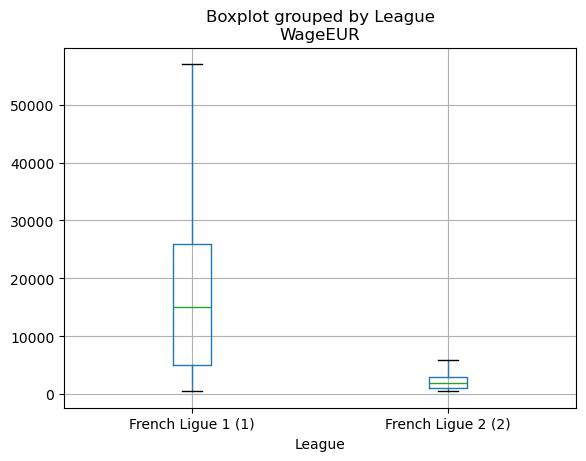

In [19]:
data_joueurs = pd.read_csv('players.csv',sep=';')
data_equipes=pd.read_csv('teams.csv',sep=';')
mask_l1=(data_equipes["League"] == "French Ligue 1 (1)") 
mask2=(data_equipes["League"] == "French Ligue 2 (2)")
data_league_french = data_equipes.loc[(mask_l1 | mask2 )]

joueurdansclubs=pd.merge(data_league_french,data_joueurs,how='inner',left_on='ID',right_on='Club_id')[['Name_x','League','ValueEUR','WageEUR' ]]

joueurdansclubs.boxplot(column = "WageEUR", by="League",showfliers = False)



**Question 3** : Afficher un diagramme en barres représentant l'évaluation des compétences en dribble, accélération, agilité et vision de jeu (`Dribbling`, `Acceleration`, `Agility`, `Vision`) pour un joueur dont on spécifie l'identifiant `ID`.

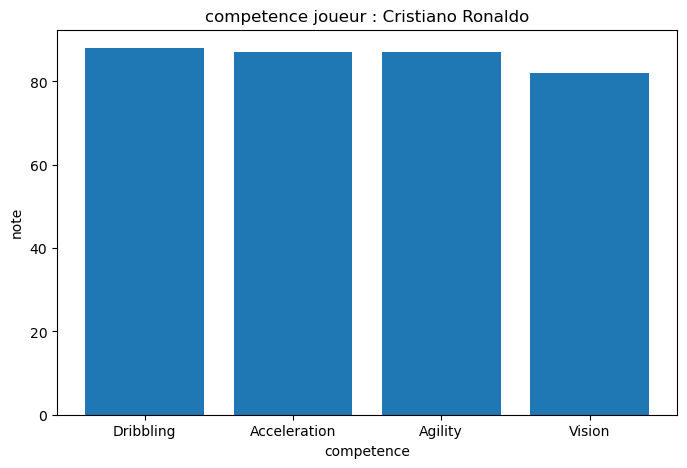

In [20]:
id_joueur = 20801   # mettre id joueur qu'on veux 

joueur = data_joueurs.loc[data_joueurs["ID"] == id_joueur, 
                          ["Name", "Dribbling", "Acceleration", "Agility", "Vision"]]

competences = joueur[["Dribbling", "Acceleration", "Agility", "Vision"]].iloc[0]

plt.figure(figsize=(8,5))
plt.bar(competences.index, competences.values)
plt.title("competence joueur : " + joueur["Name"].iloc[0])
plt.ylabel("note")
plt.xlabel("competence")
plt.show()

**Question 4** : Représenter la distribution des salaires parmi les joueurs appartenant à des équipes ayant un budget de transfert supérieur ou égal à 50 millions (représentation par intervalles de 50000 euros d'amplitude).

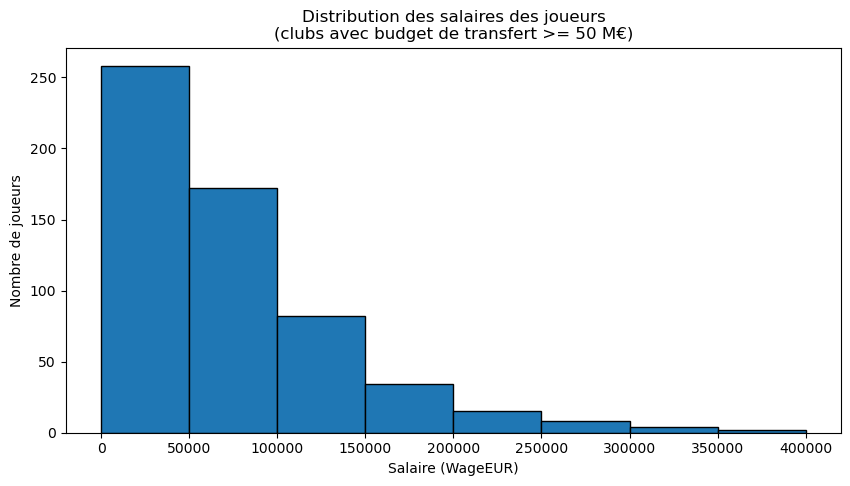

In [22]:
# equipes avec budget de transfert 50 million
equipes_budget = data_equipes.loc[data_equipes["TransferBudget"] >= 50000000]

# jointure avec les joueurs
joueurs_budget = pd.merge(
    equipes_budget,
    data_joueurs,
    how='inner',
    left_on='ID',
    right_on='Club_id'
)[["Name_x", "WageEUR"]]

# histogramme des salaires avec classes de 50 000 €
bornes = range(0, int(joueurs_budget["WageEUR"].max()) + 50000, 50000)

plt.figure(figsize=(10,5))
plt.hist(joueurs_budget["WageEUR"], bins=bornes, edgecolor="black")
plt.title("Distribution des salaires des joueurs\n(clubs avec budget de transfert >= 50 M€)")
plt.xlabel("Salaire (WageEUR)")
plt.ylabel("Nombre de joueurs")
plt.show()